<div style="display: flex; align-items: center; gap: 20px; background-color: rgba(9, 169, 36, 0.72); padding: 20px; border-radius: 10px; color: white;">
  <img src="logo_udea.png" alt="Logo UdeA" style="height: 80px;">
  <div>
    <h1 style="margin: 0; font-size: 2em;">Proyecto 2 - Análisis espectral de señales ECG</h1>
    <p style="margin: 2px 0 0 0; font-size: 1.3em;"><strong>Bioseñales y Sistemas</strong></p>
    <p style="margin: 10px 0 0 0; font-size: 1.2em;">Universidad de Antioquia - Facultad de Ingeniería</p>
    <p style="margin: 5px 0 0 0; font-size: 1em;">Integrantes: Luisa Taho, Liseth Tiria, Victor Ocampo</p>
    <p style="margin: 5px 0 0 0; font-size: 1em;">Profesores: John Fredy Ochoa, Juliana Moreno Rada</p>
  </div>
</div>



# Importación de librerías y funciones

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.signal as signal
from scipy import fft
from scipy.fftpack import dct
import matplotlib.pyplot as plt;
import scipy.io as sio;
import seaborn as sns
from scipy.signal import detrend
from scipy.signal import butter, filtfilt
from scipy.stats import kstest, zscore, kruskal
from scipy.stats import ttest_ind, shapiro, levene, mannwhitneyu
from scipy import stats
import os
import librosa
import neurokit2 as nk
import zipfile
from scipy.signal import welch

# Cargue del dataset

### a) Cargue del archivo "Diagnostics.xlsx'

In [3]:
data = pd.read_excel('C:\Programación\Bioseñales\proyecto2_ekg\Diagnostics.xlsx')
data

,FileName,Rhythm,Beat,PatientAge,Gender,VentricularRate,AtrialRate,QRSDuration,QTInterval,QTCorrected,RAxis,TAxis,QRSCount,QOnset,QOffset,TOffset
0,MUSE_20180113_171327_27000,AFIB,RBBB TWC,85,MALE,117,234,114,356,496,81,-27,19,208,265,386
1,MUSE_20180112_073319_29000,SB,TWC,59,FEMALE,52,52,92,432,401,76,42,8,215,261,431
2,MUSE_20180111_165520_97000,SA,NONE,20,FEMALE,67,67,82,382,403,88,20,11,224,265,415
3,MUSE_20180113_121940_44000,SB,NONE,66,MALE,53,53,96,456,427,34,3,9,219,267,447
4,MUSE_20180112_122850_57000,AF,STDD STTC,73,FEMALE,162,162,114,252,413,68,-40,26,228,285,354
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10641,MUSE_20181222_204306_99000,SVT,NONE,80,FEMALE,196,73,168,284,513,258,244,32,177,261,319
10642,MUSE_20181222_204309_22000,SVT,NONE,81,FEMALE,162,81,162,294,482,110,-75,27,173,254,320
10643,MUSE_20181222_204310_31000,SVT,NONE,39,MALE,152,92,152,340,540,250,38,25,208,284,378
10644,MUSE_20181222_204312_58000,SVT,NONE,76,MALE,175,178,128,310,529,98,-83,29,205,269,360


### Extracción de los registros con ritmos tipo AFIB, SB y SR.

In [33]:
dataSB_FileName = data.loc[lambda x: x["Rhythm"] == "SB", "FileName"].tolist()
dataAFIB_FileName = data.loc[lambda x: x["Rhythm"] == "AFIB", "FileName"].tolist()
dataSR_FileName = data.loc[lambda x: x["Rhythm"] == "SR", "FileName"].tolist()

print(f"Cantidad de archivos para SB (bradicardia sinusal): {len(dataSB_FileName)}")
print(f"Cantidad de archivos para AFIB (fibrilación auricular): {len(dataAFIB_FileName)}")
print(f"Cantidad de archivos para SR (ritmo sinusal): {len(dataSR_FileName)}")

Cantidad de archivos para SB (bradicardia sinusal): 3889
Cantidad de archivos para AFIB (fibrilación auricular): 1780
Cantidad de archivos para SR (ritmo sinusal): 1826


In [34]:

dataAFIB_FileName_csv = [f"{archivo}.csv" for archivo in dataAFIB_FileName]
dataSB_FileName_csv = [f"{archivo}.csv" for archivo in dataSB_FileName]
dataSR_FileName_csv = [f"{archivo}.csv" for archivo in dataSR_FileName]

In [29]:
directorio_actual = os.getcwd()
folder = os.listdir(directorio_actual+"/ECGDataDenoised/ECGDataDenoised")

Se recorre la carpeta con todas las señales para extraer las que corresponden a los ritmos de interés.

In [35]:
SB_registers = []
AFIB_registers = []
SR_registers = []

for archivo in folder:
    if archivo in dataSB_FileName_csv:
        SB_registers.append(archivo)
    if archivo in dataAFIB_FileName_csv:
        AFIB_registers.append(archivo)
    if archivo in dataSR_FileName_csv:
        SR_registers.append(archivo)
    




In [36]:
len(SB_registers), len(AFIB_registers), len(SR_registers)

(3889, 1780, 1826)

Creación de un DataFrame para almancenar las señales de interés y su etiqueta., 

In [ ]:
dataset = []
for registro in SB_registers:
    dataset.append({'Registro': registro, 'Ritmo': 'SB'})

for registro in AFIB_registers:
    dataset.append({'Registro': registro, 'Ritmo': 'AFIB'})

for registro in SR_registers:
    dataset.append({'Registro': registro, 'Ritmo': 'SR'})

dataframe_ritmos = pd.DataFrame(dataset)

print(dataframe_ritmos)

                            Registro Ritmo
0     MUSE_20180111_155758_17000.csv    SB
1     MUSE_20180111_155839_67000.csv    SB
2     MUSE_20180111_155859_36000.csv    SB
3     MUSE_20180111_155907_78000.csv    SB
4     MUSE_20180111_160033_11000.csv    SB
...                              ...   ...
7490  MUSE_20180210_133122_64000.csv    SR
7491  MUSE_20180210_133123_70000.csv    SR
7492  MUSE_20180210_133136_06000.csv    SR
7493  MUSE_20180210_133138_18000.csv    SR
7494  MUSE_20180210_133139_22000.csv    SR

[7495 rows x 2 columns]


#### Señales de la derivación II

In [46]:
def derivacion_dos(carpeta, archivo, columnas):
    ruta = os.path.join(carpeta, archivo) 
    try:
        df = pd.read_csv(ruta, delimiter=',', names=columnas)
        signal = df["II"]
    except FileNotFoundError:
        print(f'El archivo {archivo} no se encontró en {carpeta}.')
    return signal

In [47]:
df_SB_files = dataframe_ritmos[dataframe_ritmos['Ritmo'] == 'SB']
df_AFIB_files = dataframe_ritmos[dataframe_ritmos['Ritmo'] == 'AFIB']
df_SR_files = dataframe_ritmos[dataframe_ritmos['Ritmo'] == 'SR']


columnas = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
ruta = directorio_actual + "/ECGDataDenoised/ECGDataDenoised"

lista_SB_II = []
lista_AFIB_II = []
lista_SR_II = []

for archivo in df_SB_files['Registro']:
    signal = derivacion_dos(ruta, archivo, columnas)
    data = {"Registros": archivo, "II": signal, "Ritmo": "SB"}
    lista_SB_II.append(data)

for archivo in df_AFIB_files['Registro']:
    signal = derivacion_dos(ruta, archivo, columnas)
    data = {"Registros": archivo, "II": signal, "Ritmo": "AFIB"}
    lista_AFIB_II.append(data)

for archivo in df_SR_files['Registro']:
    signal = derivacion_dos(ruta, archivo, columnas)
    data = {"Registros": archivo, "II": signal, "Ritmo": "SR"}
    lista_SR_II.append(data)



df_signals = pd.DataFrame(lista_SB_II + lista_AFIB_II + lista_SR_II)
df_signals.index = df_signals.index + 1


In [48]:
df_signals

,Registros,II,Ritmo
1,MUSE_20180111_155758_17000.csv,0 362.880 1 310.670 2 263.87...,SB
2,MUSE_20180111_155839_67000.csv,0 20.0040 1 22.1440 2 22.996...,SB
3,MUSE_20180111_155859_36000.csv,0 -3.03400 1 -2.30080 2 -1.0...,SB
4,MUSE_20180111_155907_78000.csv,0 -26.45100 1 -8.01570 2 ...,SB
5,MUSE_20180111_160033_11000.csv,0 11.3730 1 4.3521 2 -1.206...,SB
...,...,...,...
7491,MUSE_20180210_133122_64000.csv,0 -26.554 1 -28.265 2 -30.05...,SR
7492,MUSE_20180210_133123_70000.csv,0 16.2330 1 4.2384 2 -6....,SR
7493,MUSE_20180210_133136_06000.csv,0 31.0470 1 25.4140 2 22....,SR
7494,MUSE_20180210_133138_18000.csv,0 -6.0006 1 -3.2482 2 -1.456...,SR


In [ ]:
def guardar_archivos(df, carpeta): #Función para guardar los registros de la II derivación
    for _, row in df.iterrows():
        nombre_archivo = row['Registros'] 
        señal = row['II']  
        ruta_guardar = os.path.join(carpeta, nombre_archivo)
        
        
        with open(ruta_guardar, 'w') as f:
            for dato in señal:
                f.write(f"{dato}\n")

In [ ]:
sb_folder = "SB" 
afib_folder = "AFIB"
sr_folder = "SR"

df_SB = df_signals[df_signals['Ritmo'] == 'SB'] 
df_AFIB = df_signals[df_signals['Ritmo'] == 'AFIB']
df_SR = df_signals[df_signals['Ritmo'] == 'SR']

if not os.path.exists(sb_folder):
    os.makedirs(sb_folder)
    print(f"Carpeta '{sb_folder}' creada.")
    guardar_archivos(df_SB, sb_folder)
    print('Archivos de SB guardados correctamente')
else:
    print(f"Carpeta '{sb_folder}' ya existe.")

if not os.path.exists(afib_folder):
    os.makedirs(afib_folder)
    print(f"Carpeta '{afib_folder}' creada.")
    guardar_archivos(df_AFIB, afib_folder)
    print('Archivos de AFIB guardados correctamente')
else:
    print(f"Carpeta '{afib_folder}' ya existe.")

if not os.path.exists(sr_folder):
    os.makedirs(sr_folder)
    print(f"Carpeta '{sr_folder}' creada.")
    guardar_archivos(df_SR, sr_folder)
    print('Archivos de SR guardados correctamente')
else:
    print(f"Carpeta '{sr_folder}' ya existe.")

Carpeta 'SB' creada.
Archivos de SB guardados correctamente
Carpeta 'AFIB' creada.
Archivos de AFIB guardados correctamente
Carpeta 'SR' creada.
Archivos de SR guardados correctamente


In [7]:

def cargar_senal_csv(ruta_archivo):
    """Carga una señal desde un archivo CSV"""
    df = pd.read_csv(ruta_archivo, header=None)
    return df.iloc[:, 0].dropna().astype(float).values


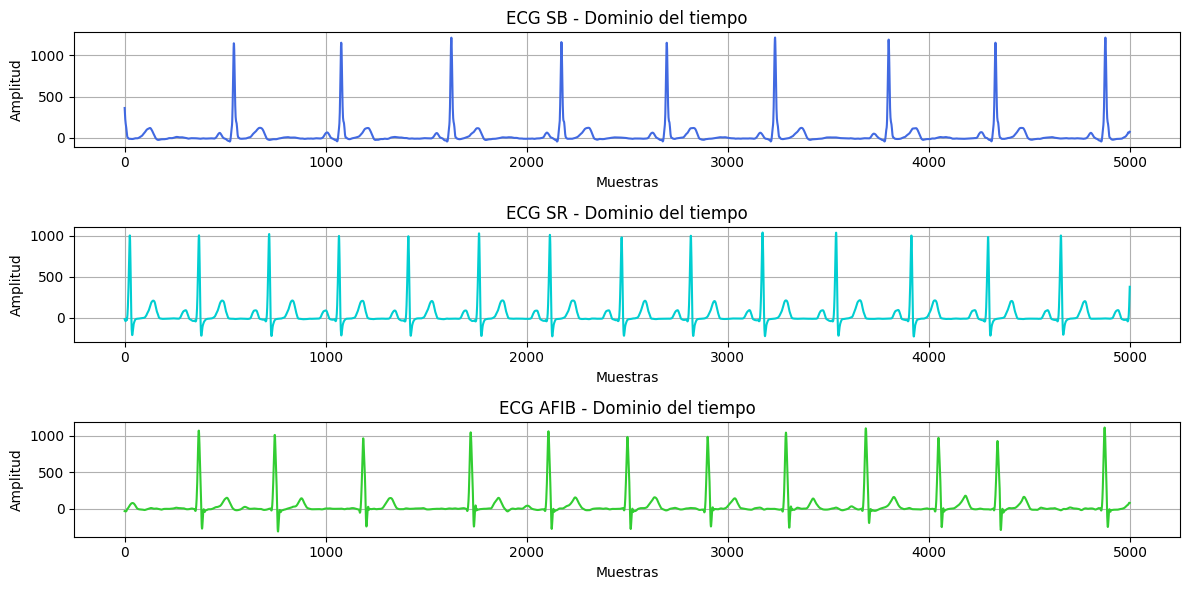

In [8]:
senal_sb = cargar_senal_csv(r'C:\Programación\Bioseñales\proyecto2_ekg\proyecto2_ecg_\SB\MUSE_20180111_155758_17000.csv')
senal_sr = cargar_senal_csv(r'C:\Programación\Bioseñales\proyecto2_ekg\proyecto2_ecg_\SR\MUSE_20180209_111618_08000.csv')
senal_afib = cargar_senal_csv(r'C:\Programación\Bioseñales\proyecto2_ekg\proyecto2_ecg_\AFIB\MUSE_20180111_160140_78000.csv')

colores = ['royalblue', 'darkturquoise', 'limegreen']


plt.figure(figsize=(12, 6))

# SB
plt.subplot(3, 1, 1)
plt.plot(senal_sb, color=colores[0])
plt.title('ECG SB - Dominio del tiempo')
plt.xlabel('Muestras')
plt.ylabel('Amplitud')
plt.grid(True)

# SR
plt.subplot(3, 1, 2)
plt.plot(senal_sr, color=colores[1])
plt.title('ECG SR - Dominio del tiempo')
plt.xlabel('Muestras')
plt.ylabel('Amplitud')
plt.grid(True)

# AFIB
plt.subplot(3, 1, 3)
plt.plot(senal_afib, color=colores[2])
plt.title('ECG AFIB - Dominio del tiempo')
plt.xlabel('Muestras')
plt.ylabel('Amplitud')
plt.grid(True)

plt.tight_layout()
plt.show()


# Extracción de características 

## Extracción de características usando la Transformada Discreta de Fourier

### Transformada rápida de Fourier (FFT) a las señales 

La DFT (Transformada discreta de Fourier) se usa para analizar la distribución espectral de una señal ECG, puesto que muchas anormalidades cardíacas introducen componentes de frecuencia que no están presentes en señales normales. Sin embargo el costo computacional de la DFT es muy alto, por lo que se recurre a un método más rápido, llamado FFT (Transformada rápida de Fourier)

In [60]:

def transformada_fft(senal, fs=500):
    n = len(senal)
    fft_vals = np.fft.fft(senal)
    freqs = np.fft.fftfreq(n, d=1/fs)
    magnitudes = np.abs(fft_vals)
    return freqs[:n // 2], magnitudes[:n // 2]

def procesar_carpeta(nombre_carpeta, etiqueta):
    resultados = []
    for archivo in os.listdir(nombre_carpeta):
        ruta = os.path.join(nombre_carpeta, archivo)
        try:
            senal = cargar_senal_csv(ruta)
            if len(senal) != 5000:
                print(f"Omitiendo {archivo}: tamaño inesperado {len(senal)}")
                continue
            freqs, mags = transformada_fft(senal)
            for f, m in zip(freqs, mags):
                resultados.append({
                    'archivo': archivo,
                    'grupo': etiqueta,
                    'frecuencia': f,
                    'magnitud': m
                })
        except Exception as e:
            print(f"Error con {archivo}: {e}")
    return resultados

In [61]:
resultados = []
resultados += procesar_carpeta('SB', 'SB')
resultados += procesar_carpeta('AFIB', 'AFIB')
resultados += procesar_carpeta('SR', 'SR')

df_fft = pd.DataFrame(resultados)


Omitiendo MUSE_20180113_124215_52000.csv: tamaño inesperado 1926


In [62]:
df_fft


,archivo,grupo,frecuencia,magnitud
0,MUSE_20180111_155758_17000.csv,SB,0.0,180544.464437
1,MUSE_20180111_155758_17000.csv,SB,0.1,3013.153119
2,MUSE_20180111_155758_17000.csv,SB,0.2,1872.548288
3,MUSE_20180111_155758_17000.csv,SB,0.3,5833.067656
4,MUSE_20180111_155758_17000.csv,SB,0.4,2196.420104
...,...,...,...,...
18734995,MUSE_20180210_133139_22000.csv,SR,249.5,14.440216
18734996,MUSE_20180210_133139_22000.csv,SR,249.6,10.630161
18734997,MUSE_20180210_133139_22000.csv,SR,249.7,10.106600
18734998,MUSE_20180210_133139_22000.csv,SR,249.8,15.884356


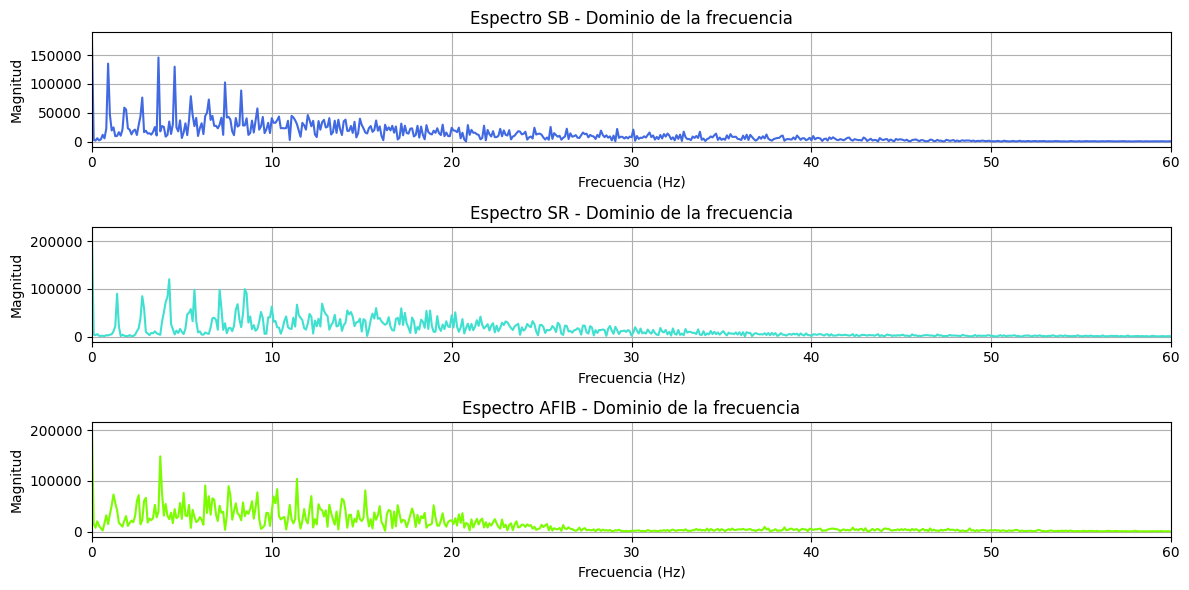

In [63]:
plt.figure(figsize=(12, 6))

# SB
plt.subplot(3, 1, 1)
df_sb = df_fft[df_fft['archivo'] == 'MUSE_20180111_155758_17000.csv']
plt.plot(df_sb['frecuencia'], df_sb['magnitud'], color=colores[0])
plt.title('Espectro SB - Dominio de la frecuencia')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud')
plt.xlim(0, 60)
plt.grid(True)

# SR
plt.subplot(3, 1, 2)
df_sr = df_fft[df_fft['archivo'] == 'MUSE_20180209_111618_08000.csv']
plt.plot(df_sr['frecuencia'], df_sr['magnitud'], color=colores[1])
plt.title('Espectro SR - Dominio de la frecuencia')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud')
plt.xlim(0, 60)
plt.grid(True)

# AFIB
plt.subplot(3, 1, 3)
df_afib = df_fft[df_fft['archivo'] == 'MUSE_20180111_160140_78000.csv']
plt.plot(df_afib['frecuencia'], df_afib['magnitud'], color=colores[2])
plt.title('Espectro AFIB - Dominio de la frecuencia')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud')
plt.xlim(0, 60)
plt.grid(True)

plt.tight_layout()
plt.show()


### Extracción de características con FFT

In [65]:

def calcular_caracteristicas(grupo_df):
    mags = grupo_df['magnitud'].values
    freqs = grupo_df['frecuencia'].values

    energy = np.sum(mags ** 2)
    peak_freq = freqs[np.argmax(mags)]
    mean_mag = np.mean(mags)
    var_mag = np.var(mags)


    # Primeros 10 coeficientes espectrales 
    coeffs = mags[:10]
    coeffs = np.pad(coeffs, (0, 10 - len(coeffs)), constant_values=0)

    return pd.Series({
        'fft_energy': energy,
        'fft_peak_freq': peak_freq,
        'fft_mean_mag': mean_mag,
        'fft_var_mag': var_mag,
        
        **{f'fft_coeff_{i}': c for i, c in enumerate(coeffs)}
    })

# Agrupar por archivo
fft_caracteristicas = df_fft.groupby(['archivo', 'grupo']).apply(calcular_caracteristicas).reset_index()


C:\Users\tahol\AppData\Local\Temp\ipykernel_30056\909425704.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fft_caracteristicas = df_fft.groupby(['archivo', 'grupo']).apply(calcular_caracteristicas).reset_index()


In [66]:
fft_caracteristicas

,archivo,grupo,fft_energy,fft_peak_freq,fft_mean_mag,fft_var_mag,fft_coeff_0,fft_coeff_1,fft_coeff_2,fft_coeff_3,fft_coeff_4,fft_coeff_5,fft_coeff_6,fft_coeff_7,fft_coeff_8,fft_coeff_9
0,MUSE_20180111_155154_74000.csv,AFIB,1.464336e+11,0.0,2252.596369,5.349925e+07,110777.159595,4209.264998,4456.571325,2536.879020,1262.049605,9758.881570,11049.727192,7901.853424,8072.754539,8164.550823
1,MUSE_20180111_155203_15000.csv,AFIB,1.291414e+11,0.0,2150.559389,4.703165e+07,119868.706387,19656.817082,5717.197029,17078.524395,13515.774819,6147.071252,13290.879538,30302.538162,37971.230190,22239.514935
2,MUSE_20180111_155758_17000.csv,SB,2.828820e+11,0.0,3235.846147,1.026821e+08,180544.464437,3013.153119,1872.548288,5833.067656,2196.420104,3873.040213,11773.171332,5681.453330,22738.577025,135288.420798
3,MUSE_20180111_155839_67000.csv,SB,4.274610e+10,2.9,1256.319064,1.552010e+07,50980.215712,1549.978669,2519.373942,3111.853946,3016.059314,3465.441674,3189.097304,1690.767419,3206.022129,12212.212452
4,MUSE_20180111_155859_36000.csv,SB,1.199978e+11,0.0,1857.319797,4.454947e+07,130490.530090,3010.205689,3269.288274,10211.393760,4764.023543,5885.124218,8173.569041,14303.504005,23896.971434,108426.733292
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7489,MUSE_20180712_161449_58000.csv,AFIB,4.009579e+11,12.4,4259.518789,1.422397e+08,49512.607035,22896.342179,26292.713393,25216.940663,29331.654859,30686.722790,35888.931058,48417.510476,56249.652570,53158.471955
7490,MUSE_20180712_161451_72000.csv,AFIB,7.518653e+10,0.0,1495.972624,2.783668e+07,98426.832232,9094.660702,17870.748440,11544.345114,7111.024007,13779.610491,4313.082103,2012.176226,13681.316322,6012.144116
7491,MUSE_20180712_161452_78000.csv,AFIB,2.626611e+11,0.0,2879.405978,9.677346e+07,216906.128766,35536.174900,14147.876185,7538.895027,17746.973870,28181.816244,17806.876458,56337.061357,20177.814585,79245.697240
7492,MUSE_20180712_161503_00000.csv,AFIB,8.314556e+10,0.0,1595.150891,3.071372e+07,133710.706354,6594.186121,13817.548619,11167.153038,9642.569933,1803.699982,1990.375464,11038.972076,9252.334600,11830.924652


## Extracción de características usando la transformada discreta de coseno (DCT)

La DCT transforma una señal del dominio del tiempo al dominio de la frecuencia, como la FFT, pero usando solo cosenos reales.

**Pipeline de trabajo**

1. Filtro Butterworth (1–40 Hz) - Las señales ya se encuentran filtradas, este paso se omite
2. Detección de picos R
3. Recorte de segmentos de ECG entre R–R
4. Calcular autocorrelación (21 coeficientes)
5. Aplicar DCT a la autocorrelación
6. Guardar coeficientes DCT como características


In [12]:
def extraer_segmentos_rr_con_picos(senal, fs=500):
    try:
        signal_cleaned = nk.ecg_clean(senal, sampling_rate=fs)
        _, rpeaks_info = nk.ecg_peaks(signal_cleaned, sampling_rate=fs)
        rpeaks = rpeaks_info["ECG_R_Peaks"]
    except Exception as e:
        print(f"Error al detectar picos R: {e}")
        return []

    segmentos = []
    for i in range(1, len(rpeaks)):
        r_inicio = rpeaks[i - 1]
        r_fin = rpeaks[i]
        seg = senal[r_inicio:r_fin]
        if len(seg) > 30:
            segmentos.append((seg, r_inicio, r_fin))
    return segmentos


In [13]:
def procesar_grupo_rr_segmentos(carpeta, grupo):
    resultados = []
    for archivo in os.listdir(carpeta):
        if not archivo.endswith('.csv'):
            continue
        ruta = os.path.join(carpeta, archivo)
        try:
            senal = cargar_senal_csv(ruta)
            segmentos = extraer_segmentos_rr_con_picos(senal)
            for i, (seg, r_inicio, r_fin) in enumerate(segmentos):
                resultados.append({
                    'archivo': archivo,
                    'grupo': grupo,
                    'latido': i,
                    'segmento': seg,
                    'r_inicio': r_inicio,
                    'r_fin': r_fin
                })
        except Exception as e:
            print(f"Error en archivo {archivo}: {e}")
    return resultados



In [14]:
res_rr = []
res_rr += procesar_grupo_rr_segmentos('SB', 'SB')
res_rr += procesar_grupo_rr_segmentos('AFIB', 'AFIB')
res_rr += procesar_grupo_rr_segmentos('SR', 'SR')

df_rr = pd.DataFrame(res_rr)


In [15]:
df_rr

,archivo,grupo,latido,segmento,r_inicio,r_fin
0,MUSE_20180111_155758_17000.csv,SB,0,"[1145.8, 1134.0, 1063.6, 946.74, 802.0, 649.82...",543,1077
1,MUSE_20180111_155758_17000.csv,SB,1,"[1152.8, 1134.7, 1059.2, 939.05, 792.75, 640.4...",1077,1625
2,MUSE_20180111_155758_17000.csv,SB,2,"[1213.8, 1171.8, 1074.1, 935.55, 775.83, 615.9...",1625,2173
3,MUSE_20180111_155758_17000.csv,SB,3,"[1154.0, 1088.1, 973.73, 828.53, 672.64, 524.9...",2173,2696
4,MUSE_20180111_155758_17000.csv,SB,4,"[1152.1, 1139.2, 1067.5, 949.77, 804.44, 651.5...",2696,3235
...,...,...,...,...,...,...
77593,MUSE_20180210_133139_22000.csv,SR,4,"[654.44, 543.48, 423.04, 315.25, 233.62, 180.8...",2385,2836
77594,MUSE_20180210_133139_22000.csv,SR,5,"[708.26, 614.62, 498.53, 386.46, 296.08, 233.5...",2836,3294
77595,MUSE_20180210_133139_22000.csv,SR,6,"[659.31, 568.17, 462.06, 364.8, 288.95, 236.11...",3294,3749
77596,MUSE_20180210_133139_22000.csv,SR,7,"[660.34, 546.73, 426.02, 320.26, 240.36, 188.7...",3749,4196


In [16]:
df_rr['longitud'] = df_rr['segmento'].apply(len)
df_rr['longitud'].describe()


count    77598.000000
mean       424.076523
std        126.701459
min        151.000000
25%        330.000000
50%        431.000000
75%        526.000000
max       2684.000000
Name: longitud, dtype: float64

In [17]:
def autocorrelacion(segmento, num_coef=21):
    ac = np.correlate(segmento, segmento, mode='full')  # largo 2N-1
    ac = ac[len(ac)//2:]  # Tomamos solo la parte positiva
    return ac[:num_coef]

df_rr['autocor'] = df_rr['segmento'].apply(lambda x: autocorrelacion(x, num_coef=21))


In [19]:
df_rr

,archivo,grupo,latido,segmento,r_inicio,r_fin,longitud,autocor
0,MUSE_20180111_155758_17000.csv,SB,0,"[1145.8, 1134.0, 1063.6, 946.74, 802.0, 649.82...",543,1077,534,"[11443428.292623969, 10052111.826506441, 85577..."
1,MUSE_20180111_155758_17000.csv,SB,1,"[1152.8, 1134.7, 1059.2, 939.05, 792.75, 640.4...",1077,1625,548,"[12436235.324643642, 10932264.541233467, 93020..."
2,MUSE_20180111_155758_17000.csv,SB,2,"[1213.8, 1171.8, 1074.1, 935.55, 775.83, 615.9...",1625,2173,548,"[12520879.710581597, 10981245.830755211, 93084..."
3,MUSE_20180111_155758_17000.csv,SB,3,"[1154.0, 1088.1, 973.73, 828.53, 672.64, 524.9...",2173,2696,523,"[10251855.186907016, 8855357.525214687, 741886..."
4,MUSE_20180111_155758_17000.csv,SB,4,"[1152.1, 1139.2, 1067.5, 949.77, 804.44, 651.5...",2696,3235,539,"[12657648.506159153, 11150029.465664659, 95075..."
...,...,...,...,...,...,...,...,...
77593,MUSE_20180210_133139_22000.csv,SR,4,"[654.44, 543.48, 423.04, 315.25, 233.62, 180.8...",2385,2836,451,"[3939224.7652112697, 3346353.6659305724, 26701..."
77594,MUSE_20180210_133139_22000.csv,SR,5,"[708.26, 614.62, 498.53, 386.46, 296.08, 233.5...",2836,3294,458,"[4071117.056693735, 3478666.682280362, 2796764..."
77595,MUSE_20180210_133139_22000.csv,SR,6,"[659.31, 568.17, 462.06, 364.8, 288.95, 236.11...",3294,3749,455,"[4383498.094611583, 3793693.297653341, 3071016..."
77596,MUSE_20180210_133139_22000.csv,SR,7,"[660.34, 546.73, 426.02, 320.26, 240.36, 188.7...",3749,4196,447,"[4070794.198518038, 3457882.367898288, 2761346..."


In [26]:
def aplicar_dct_normalizado(autocor, num_coef=10):
    # Normalización z-score
    if np.std(autocor) == 0:
        autocor_norm = np.zeros_like(autocor)
    else:
        autocor_norm = (autocor - np.mean(autocor)) / np.std(autocor)
        
    # Aplicar DCT
    return dct(autocor_norm, type=2, norm='ortho')[:num_coef]


In [27]:
df_rr['dct'] = df_rr['autocor'].apply(lambda x: aplicar_dct_normalizado(x, num_coef=10))


In [28]:
df_dct = pd.concat([
    df_rr.drop(columns=['dct']),
    pd.DataFrame(df_rr['dct'].tolist(), columns=[f'coef{i}' for i in range(10)])
], axis=1)


In [29]:
df_dct
df_dct.to_csv("df_dct.csv", index=False)

In [30]:
df_dct[[f'coef{i}' for i in range(10)]].describe()


,coef0,coef1,coef2,coef3,coef4,coef5,coef6,coef7,coef8,coef9
count,7.759800e+04,77598.000000,77598.000000,77598.000000,77598.000000,77598.000000,77598.000000,77598.000000,77598.000000,77598.000000
mean,2.010960e-18,3.936980,1.960204,0.896153,0.337579,0.188774,0.098838,0.079045,0.049333,0.044012
std,1.082678e-15,0.341092,0.606821,0.380199,0.196208,0.093268,0.053748,0.035215,0.025821,0.019066
min,-3.493541e-14,0.819619,-0.946026,-0.180737,-0.258321,-0.135916,-0.368867,-0.084513,-0.142913,-0.048973
25%,-4.360869e-16,3.730167,1.681817,0.653006,0.224148,0.132122,0.071182,0.060101,0.036737,0.034184
50%,0.000000e+00,3.953849,2.053512,0.902418,0.342149,0.195716,0.107129,0.084813,0.054625,0.047515
75%,4.360869e-16,4.166643,2.356898,1.143967,0.450588,0.249558,0.133847,0.102840,0.066380,0.056911
max,4.748502e-14,4.581880,4.053797,3.274334,4.428152,0.855756,0.419094,0.279175,0.199413,0.182812


### Extracción de características usando MFCC

El MFCC (Mel-Frequency Cepstral Coefficients) es una representación del contenido espectral de una señal transformada a un eje de percepción humana de frecuencias (escala Mel), muy usada en audio, pero útil también en señales como el ECG.

# Comparación de características entre grupos

### Análisis descriptivo e inferencial de las características DFT - FFT

#### a) Estadística descriptiva para FFT

In [77]:
fft_coeffs = [col for col in fft_caracteristicas.columns if col.startswith('fft_coeff_')]
df_fft_resumen = fft_caracteristicas[['grupo'] + fft_coeffs]

# Calcular estadísticas por grupo y coeficiente
resumen_estadistico = df_fft_resumen.groupby('grupo').agg(['mean', 'std', 'min', 'max', 'median'])
resumen_estadistico.columns = ['_'.join(col).strip() for col in resumen_estadistico.columns.values]

# Mostrar el DataFrame con las estadísticas
resumen_estadistico.reset_index(inplace=True)
resumen_estadistico


,grupo,fft_coeff_0_mean,fft_coeff_0_std,fft_coeff_0_min,fft_coeff_0_max,fft_coeff_0_median,fft_coeff_1_mean,fft_coeff_1_std,fft_coeff_1_min,fft_coeff_1_max,...,fft_coeff_8_mean,fft_coeff_8_std,fft_coeff_8_min,fft_coeff_8_max,fft_coeff_8_median,fft_coeff_9_mean,fft_coeff_9_std,fft_coeff_9_min,fft_coeff_9_max,fft_coeff_9_median
0,AFIB,137947.262387,97567.634685,454.309072,608147.640370,120062.129035,13334.541567,20188.466328,82.875425,439233.184098,...,18817.301965,23844.004182,275.052518,300696.451712,12290.052102,21166.392661,26608.517704,77.678073,386441.939546,13560.366048
1,SB,166188.638296,83256.158940,284.387915,690131.672149,163090.842767,7242.129060,8275.945229,59.006186,216712.966665,...,34273.177596,38034.409833,369.459123,334018.266386,21483.362470,70430.290745,53357.911527,491.244787,346478.793245,57398.457917
2,SR,162994.295512,90247.241364,61.754435,754471.448187,155041.084576,6411.623764,7466.307387,103.680336,113221.768280,...,9300.892973,11350.135449,38.908947,184332.154985,6513.733688,11521.162080,12486.868503,176.873935,160072.827252,7780.965959


#### b) Gráficos para las características de FFT

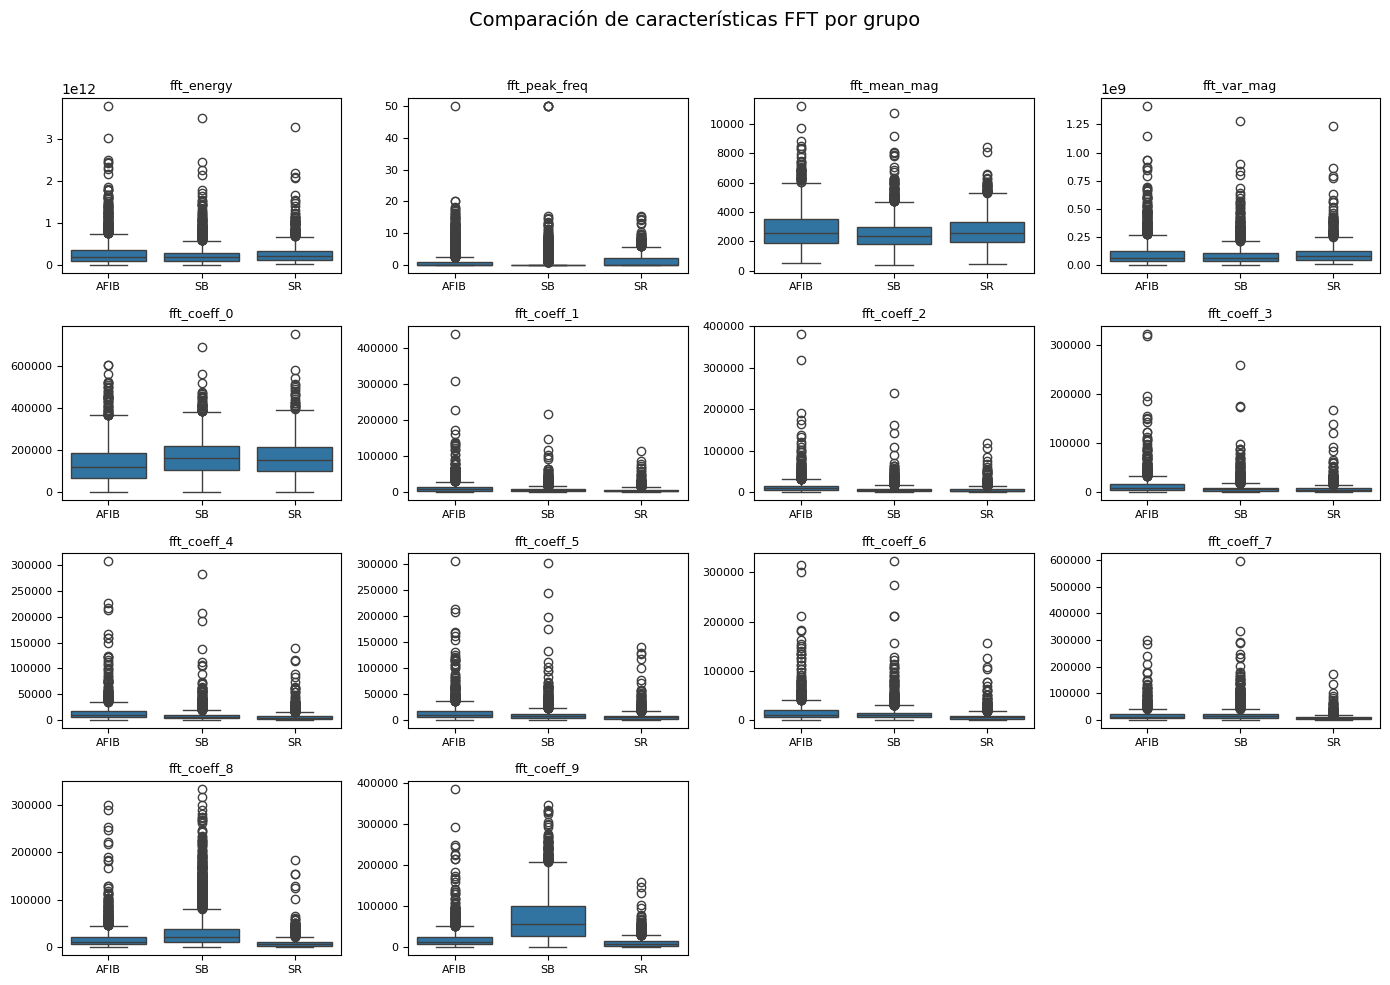

In [ ]:
cols_fft = [col for col in fft_caracteristicas.columns if col.startswith('fft_')]

n_cols = 4
n_rows = (len(cols_fft) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 2.5))
axes = axes.flatten()

for i, col in enumerate(cols_fft):
    sns.boxplot(x='grupo', y=col, data=fft_caracteristicas, ax=axes[i])
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].tick_params(labelsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Ajustar espacio
fig.suptitle('Comparación de características FFT por grupo', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()



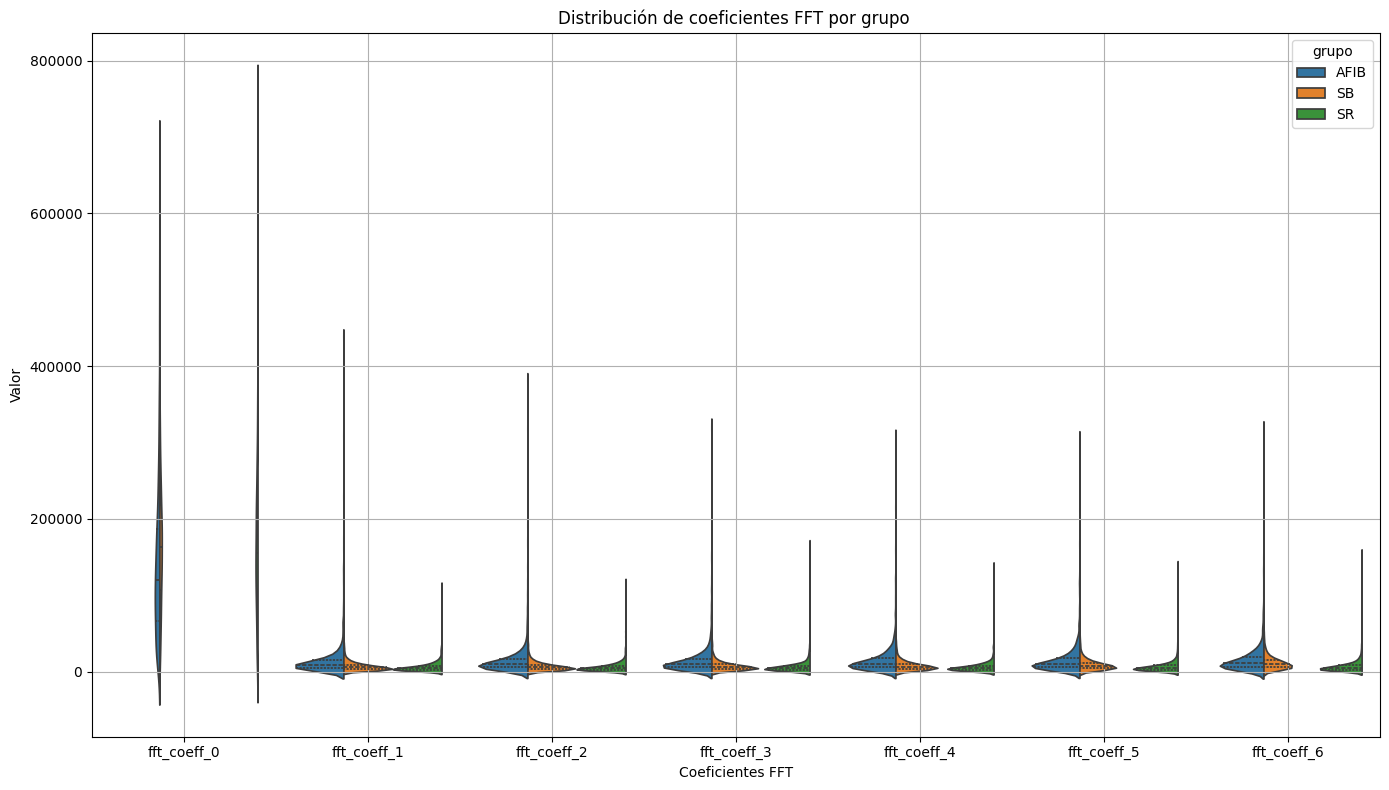

In [76]:
df_violin = fft_caracteristicas.melt(id_vars='grupo', 
                                      value_vars=[f'fft_coeff_{i}' for i in range(7)],
                                      var_name='Coeficiente', 
                                      value_name='Valor')

# Generar los violin plots
plt.figure(figsize=(14, 8))
sns.violinplot(x='Coeficiente', y='Valor', hue='grupo', data=df_violin, split=True, inner='quartile')
plt.title('Distribución de coeficientes FFT por grupo ')
plt.xlabel('Coeficientes FFT')
plt.ylabel('Valor')
plt.grid(True)
plt.tight_layout()
plt.show()

#### Pruebas de Hipótesis

In [67]:
conteo_fft = fft_caracteristicas['grupo'].value_counts()
conteo_fft_df = conteo_fft.reset_index()
conteo_fft_df.columns = ['Grupo', 'Número de muestras']
print(conteo_fft_df)


  Grupo  Número de muestras
0    SB                3888
1    SR                1826
2  AFIB                1780


Debido a que el número de muestras es menor a 5000, se aplica Shapiro Wilk:
*Hipótesis:*

**H0 (nula):** Las distribuciones de las características de los grupos son normales.

**Ha (alternativa):** Las distribuciones de las características de los grupos no son normales.



In [70]:
caracteristicas_fft = [col for col in fft_caracteristicas.columns if col.startswith('fft_') and col != 'grupo']
grupos = fft_caracteristicas['grupo'].unique()

resultados_fft_shapiro = []

for feature in caracteristicas_fft:
    for grupo in grupos:
        datos = fft_caracteristicas[fft_caracteristicas['grupo'] == grupo][feature].dropna()
        stat, p = shapiro(datos)
        resultados_fft_shapiro.append({
            'Característica': feature,
            'Grupo': grupo,
            'Shapiro p-value': p,
            'Normalidad': 'Sí' if p > 0.05 else 'No'
        })

df_fft_shapiro = pd.DataFrame(resultados_fft_shapiro)
df_fft_shapiro


,Característica,Grupo,Shapiro p-value,Normalidad
0,fft_energy,AFIB,2.072188e-49,No
1,fft_energy,SB,1.124987e-61,No
2,fft_energy,SR,1.620149e-46,No
3,fft_peak_freq,AFIB,2.167919e-58,No
4,fft_peak_freq,SB,8.926813e-83,No
5,fft_peak_freq,SR,1.220895e-53,No
6,fft_mean_mag,AFIB,3.382152e-28,No
7,fft_mean_mag,SB,9.499202e-37,No
8,fft_mean_mag,SR,1.830323e-21,No
9,fft_var_mag,AFIB,9.200663e-50,No


Debido a que las distribuciones no son normales, se utilizará la prueba de Kruskal-Wallis para comparar las características FFT entre los grupos.

In [74]:

caracteristicas_fft = [col for col in fft_caracteristicas.columns if col.startswith('fft_') and col != 'grupo']
grupos = fft_caracteristicas['grupo'].unique()

resultados_kw_fft = []

for feature in caracteristicas_fft:
    datos_por_grupo = [fft_caracteristicas[fft_caracteristicas['grupo'] == grupo][feature].dropna() for grupo in grupos]
    stat, p = kruskal(*datos_por_grupo)
    resultados_kw_fft.append({
        'Característica': feature,
        'H (estadístico)': stat,
        'p-value': p
    })

df_kw_fft = pd.DataFrame(resultados_kw_fft)

fft_significativas = df_kw_fft[df_kw_fft['p-value'] < 0.05]
fft_significativas


,Característica,H (estadístico),p-value
0,fft_energy,45.959152,1.047362e-10
1,fft_peak_freq,204.263077,4.414040e-45
2,fft_mean_mag,105.369669,1.316034e-23
3,fft_var_mag,45.237733,1.502281e-10
4,fft_coeff_0,196.866325,1.782463e-43
5,fft_coeff_1,590.978907,4.683396e-129
6,fft_coeff_2,728.350601,6.929096e-159
7,fft_coeff_3,645.396412,7.144138e-141
8,fft_coeff_4,728.699602,5.819585e-159
9,fft_coeff_5,649.567299,8.876736e-142



Los resultados mostraron que todas las características  presentaron diferencias estadísticamente significativas (p < 0.05), lo cual sugiere que la componente frecuencial de la señal ECG varía de manera sistemática entre los tres grupos de arritmias.

### Análisis descriptivo e inferencial de las características DCT

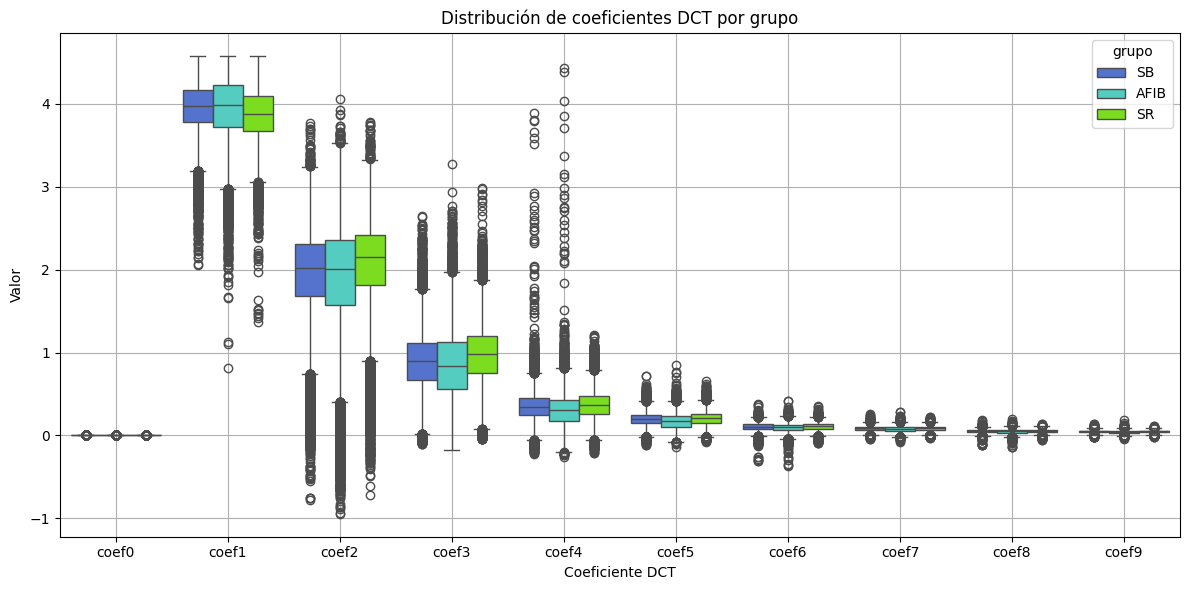

In [38]:

orden_grupos = ['SB', 'AFIB', 'SR']
colores = ['royalblue', 'turquoise', 'lawngreen']

# Convertir a formato largo
df_dct_long = df_dct.melt(id_vars=['grupo'], 
                          value_vars=[f'coef{i}' for i in range(10)],
                          var_name='Coeficiente', 
                          value_name='Valor')

# Gráfico de cajas con colores personalizados
plt.figure(figsize=(12, 6))
sns.boxplot(
    x='Coeficiente',
    y='Valor',
    hue='grupo',
    data=df_dct_long,
    palette=dict(zip(orden_grupos, colores)),
    order=[f'coef{i}' for i in range(10)],
    hue_order=orden_grupos
)

plt.title('Distribución de coeficientes DCT por grupo')
plt.xlabel('Coeficiente DCT')
plt.ylabel('Valor')
plt.grid(True)
plt.tight_layout()
plt.show()



### Pruebas estadísticas para características DCT

Primero debemos identificar cuántos datos tenemos por grupo para identificar qué tipo de prueba debemos usar

In [39]:
conteo_grupos = df_dct['grupo'].value_counts()
conteo_grupos_df = conteo_grupos.reset_index()
conteo_grupos_df.columns = ['Grupo', 'Número de latidos']
print(conteo_grupos_df)


  Grupo  Número de latidos
0    SB              31881
1  AFIB              25066
2    SR              20651


El número de muestras por grupo supera 5000, por lo que no podemos aplicar Shapiro-Wilk, en su lugar debemos aplicar Kolmogorov-Smirnov, la cual permite usar muestras grandes, para aplicar esta prueba se realizó una normalización z-score la cual tansforma los datos para que tengan media 0 y desviación estándar 1. Esto asegura que los valores evaluados puedan ser comparados con una distribución normal estándar, lo cual es un requisito del test Kolmogorov-Smirnov.

*Hipótesis:*

**H0 (nula):** Las distribuciones de los coeficientes de los grupos son normales.

**Ha (alternativa):** Las distribuciones de los coeficientes de los grupos no son normales.

In [43]:
# Lista de coeficientes
coeficientes = [f'coef{i}' for i in range(10)]
grupos = df_dct['grupo'].unique()

# Lista para guardar resultados
resultados = []

# Iterar sobre cada coeficiente y grupo
for coef in coeficientes:
    for grupo in grupos:
        datos = df_dct[df_dct['grupo'] == grupo][coef].dropna()
        datos_norm = zscore(datos)  # normalización z-score
        stat, p = kstest(datos_norm, 'norm')
        resultados.append({
            'Coeficiente': coef,
            'Grupo': grupo,
            'KS p-value': p,
            'Normalidad': 'Normal' if p > 0.05 else 'No'
        })

# Convertir a DataFrame
df_normalidad = pd.DataFrame(resultados)
df_normalidad


,Coeficiente,Grupo,KS p-value,Normalidad
0,coef0,SB,1.273826e-209,No
1,coef0,AFIB,0.000000e+00,No
2,coef0,SR,4.345891e-119,No
3,coef1,SB,2.108737e-25,No
4,coef1,AFIB,2.081095e-56,No
5,coef1,SR,3.828888e-11,No
6,coef2,SB,7.124885e-186,No
7,coef2,AFIB,1.160267e-134,No
8,coef2,SR,6.756365e-141,No
9,coef3,SB,1.054701e-10,No


Ninguna de las características presenta una distribución normal, por lo que se debe aplicar una prueba no paramétrica para evaluar si hay diferencias significativas, para ello se utilizó Kruskal Wallis, no se aplicó U de Mann Whitney debido a que son 3 grupos.

*Hipótesis:*

**H0 (nula):** Las distribuciones del coeficiente DCT son iguales entre los grupos SB, AFIB y SR.

**Ha (alternativa):** Al menos un grupo difiere significativamente en la distribución del coeficiente DCT.

In [ ]:

# Lista de coeficientes
coeficientes = [f'coef{i}' for i in range(10)]

# Lista para guardar resultados
resultados_kw = []

for coef in coeficientes:
    datos_sb = df_dct[df_dct['grupo'] == 'SB'][coef].dropna()
    datos_afib = df_dct[df_dct['grupo'] == 'AFIB'][coef].dropna()
    datos_sr = df_dct[df_dct['grupo'] == 'SR'][coef].dropna()

    stat, p = kruskal(datos_sb, datos_afib, datos_sr)

    resultados_kw.append({
        'Coeficiente': coef,
        'H (estadístico)': stat,
        'p-value': p
    })

# Convertir a DataFrame
df_kruskal = pd.DataFrame(resultados_kw)
df_significativos = df_kruskal[df_kruskal['p-value'] < 0.05]
df_significativos


,Coeficiente,H (estadístico),p-value
1,coef1,1183.121077,1.226090e-257
2,coef2,927.831735,3.341171e-202
3,coef3,1396.428894,5.879203e-304
4,coef4,1353.878236,1.021119e-294
5,coef5,2207.888472,0.000000e+00
6,coef6,778.545801,8.728254e-170
7,coef7,1475.930789,0.000000e+00
8,coef8,510.363672,1.499467e-111
9,coef9,1168.857302,1.534129e-254


Se evidenciaron diferencias estadísticamente significativas entre los tres grupos para todos los coeficientes, excepto para el coef 0. Para ver características específicas diferenciables entre cada grupo, se aplicó U -Mann Whitney entre pares, sin embargo estas pruebas no arrojaron información adicional a la obtenida anteriormente.

### Análisis descriptivo e inferencial de las características MFCC